# Importing Libraries

In [32]:
import zipfile
import librosa
import soundfile
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Loading Dataset

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
zip_path = "/content/drive/MyDrive/RAVDESS.zip"  # change path if needed
extracted_path = "/content/RAVDESS"

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

print("Files extracted to:", extracted_path)

Files extracted to: /content/RAVDESS


# Feature Extraction (MFCC)

In [20]:
def extract_features(file):
    try:
        with soundfile.SoundFile(file) as sound:
            X_audio = sound.read(dtype='float32')
            sample_rate = sound.samplerate

            # Convert stereo → mono
            if X_audio.ndim > 1:
                X_audio = librosa.to_mono(X_audio.T)

            # Skip empty or short clips
            if len(X_audio) < 2048:
                print(f"Skipping {file}: too short ({len(X_audio)} samples).")
                return None

            # Handle silence (low energy)
            if np.sum(np.abs(X_audio)) < 0.01:
                print(f"Skipping {file}: almost silent.")
                return None

            # Extract STFT safely
            n_fft = min(2048, len(X_audio))  # Prevents warning
            stft = np.abs(librosa.stft(X_audio, n_fft=n_fft))

            # Feature extraction
            mfccs = np.mean(librosa.feature.mfcc(y=X_audio, sr=sample_rate, n_mfcc=40).T, axis=0)
            chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
            mel = np.mean(librosa.feature.melspectrogram(y=X_audio, sr=sample_rate).T, axis=0)
            contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate).T, axis=0)

            # Combine
            features = np.hstack([mfccs, chroma, mel, contrast])
            return features

    except Exception as e:
        print(f"Error processing {file}: {e}")
        return None


# Build Dataset

In [21]:
emotions = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X,y = [],[]

features_list = []

for subdir, dirs, files in os.walk(extracted_path):
    for file in tqdm(files):
        if file.endswith(".wav"):
            file_path = os.path.join(subdir, file)
            file_name = os.path.basename(file)
            emotion_code = file_name.split("-")[2]
            emotion = emotions.get(emotion_code)

            # Extract features
            features = extract_features(file_path)
            features = [f for f in features if f is not None]

            # Append
            features_list.append([features, emotion])

0it [00:00, ?it/s]
100%|██████████| 60/60 [00:03<00:00, 16.43it/s]
0it [00:00, ?it/s]
100%|██████████| 60/60 [00:03<00:00, 15.88it/s]


In [22]:
X, Y = zip(*features_list)
X = np.array(X)
Y = np.array(Y)

print("Feature shape:", X.shape)
print("Labels shape:", Y.shape)

Feature shape: (2880, 187)
Labels shape: (2880,)


In [23]:
df = pd.DataFrame(X)
df['emotion'] = Y
df.to_csv("ravdess_features.csv", index=False)
print("Features saved as ravdess_features.csv")

Features saved as ravdess_features.csv


In [24]:
data = pd.read_csv("ravdess_features.csv")
data.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,emotion
0,-613.019836,55.149410,3.194921,12.161333,0.879813,11.947279,-5.544395,9.299107,-8.140087,-5.988986,...,2.747892e-08,7.927556e-09,14.933711,12.296627,14.573856,14.901444,17.533209,16.524572,20.192561,surprised
1,-745.797607,80.095909,14.088290,23.498205,8.414594,15.668051,-4.337486,16.080759,-3.479269,0.059715,...,7.862057e-09,7.556819e-09,15.407226,12.401082,14.273959,14.164754,16.820123,15.772746,18.437742,calm
2,-650.558105,62.038345,8.731860,15.758361,3.230213,11.115847,-7.142115,11.028909,-5.964324,-5.082034,...,2.851014e-08,7.941337e-09,14.985946,11.986273,14.792621,14.941372,16.823151,16.038825,19.692639,surprised
3,-672.263000,81.345085,-1.602487,7.897632,12.350101,13.619333,-6.254328,1.628198,-10.516830,-11.310380,...,1.013156e-08,7.952964e-09,14.006567,14.371795,14.777668,15.944428,18.806813,18.029556,18.631058,sad
4,-478.316772,43.466179,-21.455143,1.411139,1.148609,1.112037,-15.069955,5.267017,-7.646765,-9.651752,...,6.256171e-07,1.079954e-08,19.687305,15.717095,17.882669,17.089561,19.058929,19.265580,23.881992,fearful


# Train/Test Split

In [25]:
X = data.drop('emotion', axis=1)
Y = data['emotion']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_encoded, test_size=0.2, random_state=42)

# LSTM Model Building

In [26]:
model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,864 (1.17 MB)

 Trainable params: 305,864 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=300)

Epoch 1/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2137 - loss: 1.9949 - val_accuracy: 0.2257 - val_loss: 1.9321
Epoch 2/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2272 - loss: 1.9187 - val_accuracy: 0.2778 - val_loss: 1.8737
Epoch 3/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2825 - loss: 1.8585 - val_accuracy: 0.2639 - val_loss: 1.8597
Epoch 4/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2692 - loss: 1.8297 - val_accuracy: 0.2639 - val_loss: 1.8056
Epoch 5/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2870 - loss: 1.8079 - val_accuracy: 0.2778 - val_loss: 1.7629
Epoch 6/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3091 - loss: 1.7629 - val_accuracy: 0.2847 - val_loss: 1.7878
Epoch 7/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3213 - loss: 1.7502 - val_accuracy: 0.2622 - val_loss: 1.7936
Epoch 8/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3087 - loss: 1.7444 - val_accuracy: 0.

# Model Evaluation

Test Loss: 1.3346
Test Accuracy: 0.8559
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.83      0.85      0.84        73
        calm       0.84      0.91      0.87        65
     disgust       0.81      0.83      0.82        81
     fearful       0.87      0.86      0.86        93
       happy       0.91      0.88      0.90        83
     neutral       0.85      0.82      0.84        40
         sad       0.86      0.93      0.90        61
   surprised       0.87      0.78      0.82        80

    accuracy                           0.86       576
   macro avg       0.86      0.86      0.86       576
weighted avg       0.86      0.86      0.86       576



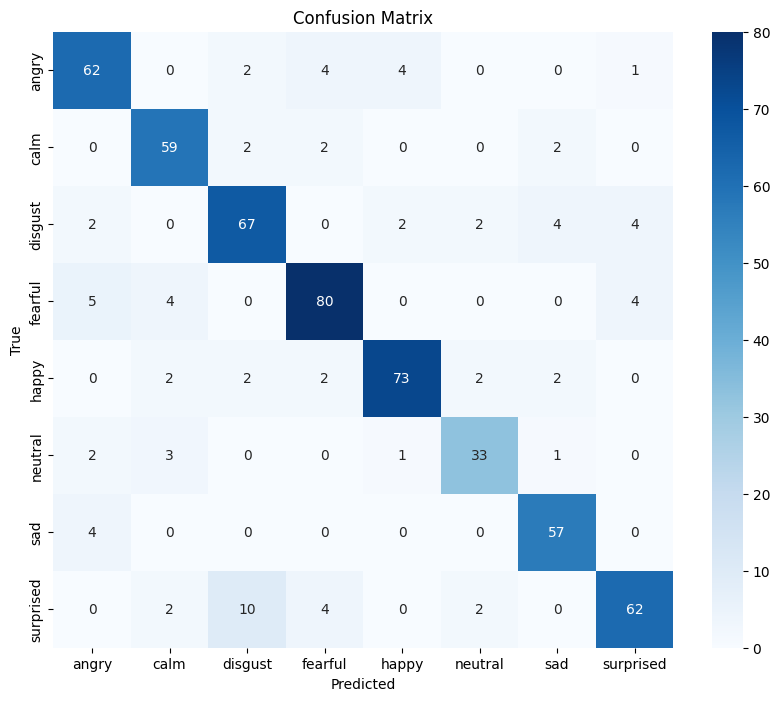

In [28]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Visualize Training History

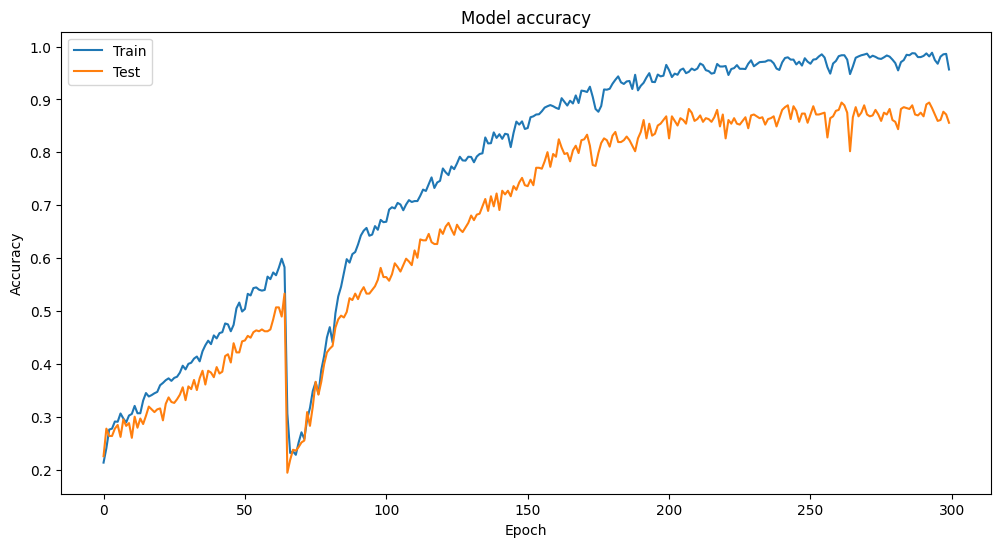

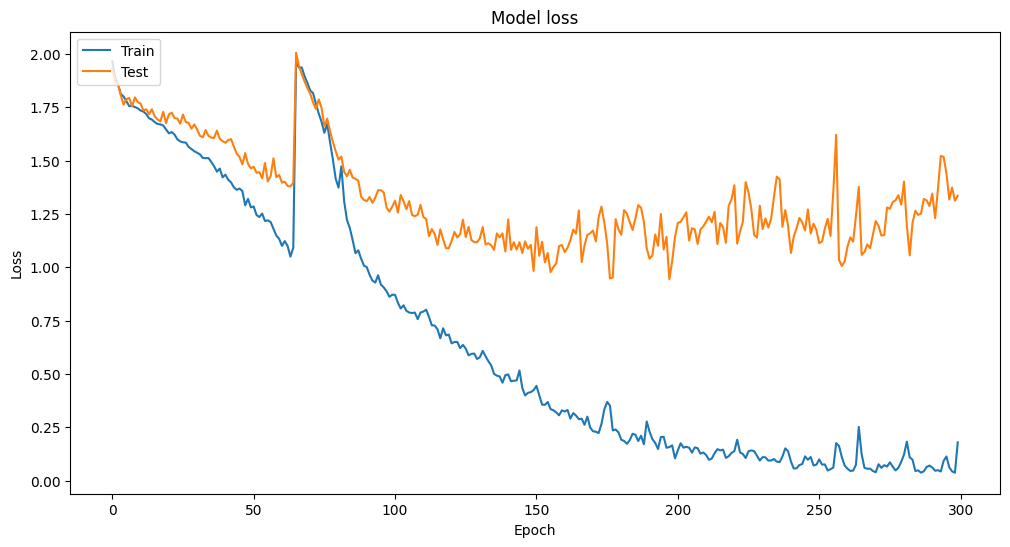

In [29]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [31]:
model.save("emotion_recognition_model.keras")

# Prediction on new Audio

In [39]:
test_audio = "/content/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav"
file = test_audio
feature = extract_features(file).reshape(1, -1, 1)
prediction = model.predict(feature)
emotion = encoder.inverse_transform([np.argmax(prediction)])[0]
print("Predicted Emotion:", emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Emotion: fearful
